# ☀️ Solar Energy Production
🇫🇷 **France — 2020 to 2026**

This notebook explores the relationship between meteorological conditions and solar energy production in France, using data from **RTE** (electricity transport network) and **Meteo-France** (weather data).

## 📁 Project Structure
```
📁 Project
├── 🗒️ solar_production
├── 🗒️ RTE_concat
└── 📁 data
    ├── 📁 coordinates
    │   ├── 📄 departements-20180101.cpg
    │   ├── 📄 departements-20180101.dbf
    │   ├── 📄 departements-20180101.prj
    │   ├── 📄 departements-20180101.shp
    │   ├── 📄 departements-20180101.shx
    │   ├── 📄 departements-descriptif.txt
    │   └── 📄 LICENCE.txt
    ├── 📁 Meteo-France
    │   ├── 📄 QUOT_SIM2_2010-2019.csv
    │   └── 📄 QUOT_SIM2_previous-2020-202605.csv
    ├── 📁 RTE
    │   ├── 📁 Regions
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2013.xls
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2014.xls
    │   │   └── 📄 ...
    │   ├── 📄 rte_regions_2013.csv
    │   ├── 📄 rte_regions_2014.csv
    │   ├── 📄 rte_regions_2015.csv
    │   ├── 📄 rte_regions_2016.csv
    │   ├── 📄 rte_regions_2017.csv
    │   ├── 📄 rte_regions_2018.csv
    │   ├── 📄 rte_regions_2019.csv
    │   ├── 📄 rte_regions_2020.csv
    │   ├── 📄 rte_regions_2021.csv
    │   ├── 📄 rte_regions_2022.csv
    │   ├── 📄 rte_regions_2023.csv
    │   ├── 📄 rte_regions_2024.csv
    │   └── 📄 rte_regions_en_cours.csv
    └── 📁 solar_installations
        └── 📄 statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx
```

# ⬇️ 1. Modules imports & loading data 

### &nbsp;&nbsp;&nbsp; A. Modules

In [45]:
# Imports for data
import numpy as np
import pandas as pd

# Imports for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Imports for machine learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

# Geoloc converter
import geopandas as gpd
from pyproj import Transformer

# Other
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")
import requests
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

### &nbsp;&nbsp;&nbsp; B. Files and settings

In [46]:
# RTE datasource: 
# https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs
# The files used are the aggregation per year of the regions datasets
PATH_RTE = 'data/RTE/' # Change this value to link to the RTE files

# Meteo-France datasource: 
# https://www.data.gouv.fr/datasets/donnees-changement-climatique-sim-quotidienne
PATH_MF = 'data/Meteo-France/' # Change this value to link to the MF files
mf_files_name = ['QUOT_SIM2_previous-2020-202605.csv']

# Solar pannel installation over time:
# https://www.statistiques.developpement-durable.gouv.fr/tableau-de-bord-solaire-photovoltaique-premier-trimestre-2026
PATH_SOLAR_INSTALL = 'data/solar_installations/' # Change this value to link to the MF files
solar_install = 'statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx'

# Coordinates conversion to départements and régions:
# https://www.data.gouv.fr/datasets/contours-des-departements-francais-issus-d-openstreetmap
COORDINATES = 'data/coordinates/' # Change this value to link to the MF files


# Setting up date range so both datasources match
date_min = '2020-01-01' # Lower bound included
date_max = '2026-02-01' # Upper bound NOT included

# Setting up region dict so all our data are consistent and geo-compatible
region_dict = {
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations + RTE
    "Bourgogne-Franche-Comté"       : "Bourgogne-Franche-Comté", # Solar installations + RTE
    "Bretagne"                      : "Bretagne", # Solar installations + RTE
    "Centre-Val de Loire"           : "Centre-Val de Loire", # Solar installations
    "Centre-Val-de-Loire"           : "Centre-Val de Loire", # RTE  
    "Grand Est"                     : "Grand Est", # Solar installations
    "Grand-Est"                     : "Grand Est", # RTE  
    "Hauts-de-France"               : "Hauts-de-France", # Solar installations + RTE
    "Normandie"                     : "Normandie", # Solar installations + RTE
    "Nouvelle-Aquitaine"            : "Nouvelle-Aquitaine", # Solar installations + RTE
    "Occitanie"                     : "Occitanie", # Solar installations + RTE
    "Pays de la Loire"              : "Pays de la Loire", # Solar installations
    "Pays-de-la-Loire"              : "Pays de la Loire", # RTE 
    "Provence-Alpes-Côte d'Azur"    : "Provence-Alpes-Côte d'Azur", # Solar installations
    "PACA"                          : "Provence-Alpes-Côte d'Azur", # RTE 
    "Île-de-France"                 : "Île-de-France", # Solar installations
    "Ile-de-France"                 : "Île-de-France", # RTE 
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # RTE
    "Corse"                         : "Corse",
}

### &nbsp;&nbsp;&nbsp; C. Loading RTE data

In [47]:
# Loading dataset
# The files are the aggratation per year and by region of the datasets provided by RTE
# The conversion can be done with RTE_concat notebook
df_list = []
for year in range(2020, 2025):
    file = f"{PATH_RTE}rte_regions_{year}.csv"
    # index_col=False to avoid column name offset
    # usecols to keep only the solar relative data
    # parse_dates to get proper date format while loading
    df = pd.read_csv(file, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
    df_list.append(df)

# Adding the current not consolidated data > 2024
current = f"{PATH_RTE}rte_regions_en_cours.csv"
df = pd.read_csv(current, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
df = df[df['Date'] <= date_max] # Keeping until the date_max we setted up earlier
df_list.append(df)

rte_df = pd.concat(df_list, ignore_index=True)
rte_df = rte_df.dropna(subset=['Solaire']) # Droping rows without measurements

# Converting regions' name
rte_df['region'] = rte_df['region'].map(region_dict)

print('RTE data successfully loaded !')

RTE data successfully loaded !


### &nbsp;&nbsp;&nbsp; D. Reshaping RTE data

In [48]:
# Converting to TWh: more readable and understandable than raw production
# Multipling by 0.5 because it's half an hour value to get TWh
# Divide by 1_000_000 to get TWh instead of MWh for readability
# Terrawatts hour = Megawatts × Hours / 1_000_000
rte_df['TWh'] = rte_df['Solaire'] * 0.5 / 1_000_000

# Grouping data by date
rte_df = rte_df.groupby(['Date','region'])[['Solaire', 'TWh']].sum().reset_index()
print('RTE data reshaped successfully !')

RTE data reshaped successfully !


### &nbsp;&nbsp;&nbsp; E. Loading solar installations data

In [49]:
# Load the data, there's 2 headers...
solar_install_df = pd.read_excel(f'{PATH_SOLAR_INSTALL}{solar_install}', header=[2, 3])

# Dropping unused values
solar_install_df = solar_install_df[
    solar_install_df.iloc[:, 0].notna() &                                   # Keep rows with region name
    solar_install_df.iloc[:, 2].isna() &                                    # Exclude overseas: only rows that are not na
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Total') &      # Remove Total rows
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Le parc') &    # Remove footnote 'Le parc...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('p :') &        # Remove footnote 'p :...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Source')       # Remove footnote 'Source...'
].iloc[:, [0] + list(range(3, len(solar_install_df.columns)))]              # Remove col 1 and 2 (départements str and id)


# Rename the region column
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_0': 'region'}, level=0)
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_1': 'region'}, level=1)


# Set region as index
solar_install_df = solar_install_df.set_index(('region', 'region'))
solar_install_df.index.name = 'region'


# Stack date level into rows
solar_install_df = (solar_install_df
                      .stack(level=0) # Brings the dates down as rows, leaving nombre and puissance as columns
                      .reset_index()
                      .rename(columns={'level_1': 'date'})
                     )


# Resample to daily, forward fill
solar_install_df = solar_install_df.set_index('date')

solar_install_daily = (solar_install_df
                    .drop(columns='region')          # Avoid duplicated region column
                    .groupby(solar_install_df['region'])
                    .resample('D')
                    .ffill()
                    .reset_index())

# Doing this after the forward fill to avoid start in the first day of the year
# Keep only the dates boundaries
solar_install_daily = solar_install_daily[(solar_install_daily['date'] >= date_min) & 
                                     (solar_install_daily['date'] < date_max)
                                     ]

# Converting regions' name
solar_install_daily['region'] = solar_install_daily['region'].map(region_dict)

print('Solar installations data successfully loaded !')

Solar installations data successfully loaded !


### &nbsp;&nbsp;&nbsp; F. Getting all geoloc combinaisons in our Météo-France data

In [50]:
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    # Reading the file by chunks to get a smooth data loading 
    # Keeping only X and Y coordinates
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, usecols=['LAMBX', 'LAMBY']):
        df_list.append(chunk)

geo_loc_df = pd.concat(df_list, ignore_index=True)

# Keeping all X and Y combinations into 1 dataframe to get the associated region
geo_loc_df.drop_duplicates(inplace=True)

print('Coordinates successfully loaded !')

Coordinates successfully loaded !


### &nbsp;&nbsp;&nbsp; G. Converting coordinates 

In [51]:
# ── Step 1: Define the coordinate transformer ──────────────────────────────────
# Meteo-France uses Lambert II étendu (EPSG:27572), a French grid projection
# We convert to WGS84 (EPSG:4326) which is the standard GPS lat/lon system
transformer = Transformer.from_crs("EPSG:27572", "EPSG:4326", always_xy=True)

# ── Step 2: Get unique grid points ─────────────────────────────────────────────
# The MF dataset has 50M+ rows but only 9892 unique LAMBX/LAMBY combinations
# Working on unique coordinates is much faster than converting every row
coords = geo_loc_df[['LAMBX', 'LAMBY']].drop_duplicates()

# ── Step 3: Convert Lambert coordinates to GPS lon/lat ─────────────────────────
# MF stores coordinates in decameters (units of 10m), so multiply by 100
# to get meters which is what the transformer expects
# always_xy=True ensures the order is always (longitude, latitude)
coords['lon'], coords['lat'] = transformer.transform(
    coords['LAMBX'] * 100,
    coords['LAMBY'] * 100
)

# ── Step 4: Create a GeoDataFrame from the coordinates ─────────────────────────
# GeoDataFrame is like a regular DataFrame but with a geometry column
# points_from_xy() creates Point objects from lon/lat columns
# crs="EPSG:4326" tells geopandas these are GPS coordinates
coords_gdf = gpd.GeoDataFrame(
    coords,
    geometry=gpd.points_from_xy(coords['lon'], coords['lat']),
    crs="EPSG:4326"
)

### &nbsp;&nbsp;&nbsp; H. Loading départements shapes and matching coordinates to départements

In [52]:
# ── Step 5: Load département boundaries ────────────────────────────────────────
# The shapefile contains polygon geometries of all French départements
# .to_crs("EPSG:4326") reprojects the shapefile to GPS coordinates
# so both GeoDataFrames use the same coordinate system for the join
departements = gpd.read_file('data/coordinates/departements-20180101.shp').to_crs("EPSG:4326")

# ── Step 6: Spatial join — point in polygon ────────────────────────────────────
# For each point in coords_gdf, find which département polygon it falls inside
# how='left' keeps all points even if no département is found
# predicate='within' means: the point must be strictly inside the polygon
coords_with_dep = gpd.sjoin(coords_gdf, departements, how='left', predicate='within')

# ── Step 7: Handle unmatched points ───────────────────────────────────────────
# Some points fall on borders or just outside polygons (coastal points, etc.)
# and get NaN for code_insee — split matched vs unmatched
matched   = coords_with_dep[coords_with_dep['code_insee'].notna()]
unmatched = coords_with_dep[coords_with_dep['code_insee'].isna()][['LAMBX', 'LAMBY', 'lon', 'lat', 'geometry']]

# For unmatched points, use nearest département instead of strict containment
# sjoin_nearest finds the closest polygon even if the point is outside it
unmatched_fixed = gpd.sjoin_nearest(unmatched, departements, how='left')

# ── Step 8: Combine and verify ─────────────────────────────────────────────────
# Merge matched and nearest-fixed rows back together
coords_to_region = pd.concat([matched, unmatched_fixed], ignore_index=True)
coords_to_region.drop(columns=['geometry', 'index_right', 'nuts3', 'wikipedia', 'surf_km2', 'nom', 'lon', 'lat'], inplace=True)

### &nbsp;&nbsp;&nbsp; I. Converting départements to région to match RTE's data

In [53]:
# Converting départements to région to match RTE's data
dept_to_region = {
    # Auvergne-Rhône-Alpes
    '01': 'Auvergne-Rhône-Alpes', '03': 'Auvergne-Rhône-Alpes',
    '07': 'Auvergne-Rhône-Alpes', '15': 'Auvergne-Rhône-Alpes',
    '26': 'Auvergne-Rhône-Alpes', '38': 'Auvergne-Rhône-Alpes',
    '42': 'Auvergne-Rhône-Alpes', '43': 'Auvergne-Rhône-Alpes',
    '63': 'Auvergne-Rhône-Alpes', '69': 'Auvergne-Rhône-Alpes',
    '69D': 'Auvergne-Rhône-Alpes',  # Rhône hors métropole
    '69M': 'Auvergne-Rhône-Alpes',  # Métropole de Lyon
    '73': 'Auvergne-Rhône-Alpes', '74': 'Auvergne-Rhône-Alpes',

    # Bourgogne-Franche-Comté
    '21': 'Bourgogne-Franche-Comté', '25': 'Bourgogne-Franche-Comté',
    '39': 'Bourgogne-Franche-Comté', '58': 'Bourgogne-Franche-Comté',
    '70': 'Bourgogne-Franche-Comté', '71': 'Bourgogne-Franche-Comté',
    '89': 'Bourgogne-Franche-Comté', '90': 'Bourgogne-Franche-Comté',

    # Bretagne
    '22': 'Bretagne', '29': 'Bretagne', '35': 'Bretagne', '56': 'Bretagne',

    # Centre-Val de Loire
    '18': 'Centre-Val de Loire', '28': 'Centre-Val de Loire',
    '36': 'Centre-Val de Loire', '37': 'Centre-Val de Loire',
    '41': 'Centre-Val de Loire', '45': 'Centre-Val de Loire',

    # Grand Est
    '08': 'Grand Est', '10': 'Grand Est', '51': 'Grand Est',
    '52': 'Grand Est', '54': 'Grand Est', '55': 'Grand Est',
    '57': 'Grand Est', '67': 'Grand Est', '68': 'Grand Est',
    '88': 'Grand Est',

    # Hauts-de-France
    '02': 'Hauts-de-France', '59': 'Hauts-de-France',
    '60': 'Hauts-de-France', '62': 'Hauts-de-France', '80': 'Hauts-de-France',

    # Île-de-France
    '75': 'Île-de-France', '77': 'Île-de-France', '78': 'Île-de-France',
    '91': 'Île-de-France', '92': 'Île-de-France', '93': 'Île-de-France',
    '94': 'Île-de-France', '95': 'Île-de-France',

    # Normandie
    '14': 'Normandie', '27': 'Normandie', '50': 'Normandie',
    '61': 'Normandie', '76': 'Normandie',

    # Nouvelle-Aquitaine
    '16': 'Nouvelle-Aquitaine', '17': 'Nouvelle-Aquitaine',
    '19': 'Nouvelle-Aquitaine', '23': 'Nouvelle-Aquitaine',
    '24': 'Nouvelle-Aquitaine', '33': 'Nouvelle-Aquitaine',
    '40': 'Nouvelle-Aquitaine', '47': 'Nouvelle-Aquitaine',
    '64': 'Nouvelle-Aquitaine', '79': 'Nouvelle-Aquitaine',
    '86': 'Nouvelle-Aquitaine', '87': 'Nouvelle-Aquitaine',

    # Occitanie
    '09': 'Occitanie', '11': 'Occitanie', '12': 'Occitanie',
    '30': 'Occitanie', '31': 'Occitanie', '32': 'Occitanie',
    '34': 'Occitanie', '46': 'Occitanie', '48': 'Occitanie',
    '65': 'Occitanie', '66': 'Occitanie', '81': 'Occitanie',
    '82': 'Occitanie',

    # Provence-Alpes-Côte d"Azur
    "04": "Provence-Alpes-Côte d'Azur", "05": "Provence-Alpes-Côte d'Azur", 
    "06": "Provence-Alpes-Côte d'Azur", "13": "Provence-Alpes-Côte d'Azur", 
    "83": "Provence-Alpes-Côte d'Azur", "84": "Provence-Alpes-Côte d'Azur",

    # Corse
    '2A': 'Corse', '2B': 'Corse',

    # Pays de la Loire
    '44': 'Pays de la Loire', '49': 'Pays de la Loire', '53': 'Pays de la Loire', 
    '72': 'Pays de la Loire', '85': 'Pays de la Loire',
}

coords_to_region['region'] = coords_to_region['code_insee'].map(dept_to_region)
print(f'Number of départements not match to a region: {coords_to_region['region'].isna().sum()}')  # should be 0
if coords_to_region['region'].isna().sum() == 0:
    print(f'Coordinates to region data successfully calculated and loaded')

Number of départements not match to a region: 0
Coordinates to region data successfully calculated and loaded


### &nbsp;&nbsp;&nbsp; J. Loading Météo-France data

In [54]:
# The goal is to load a chunk of data, get the associated region and aggregate it directly
# This way the loading process is way more memory efficient
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    year_chunks = []
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, parse_dates=['DATE']):
        filtered = chunk[
            (chunk['DATE'] >= date_min) &
            (chunk['DATE'] < date_max)
        ]
        # Getting region then filtering and aggregating result per year so we don't have trunkated results
        filtered = filtered.merge(coords_to_region, on=['LAMBX', 'LAMBY'], how='left')
        filtered = filtered.loc[filtered['region'] != 'Corse'].drop(columns=['LAMBX', 'LAMBY'])
        year_chunks.append(filtered)

    # Aggregate only after all chunks of the file are loaded
    year_mf_df = pd.concat(year_chunks, ignore_index=True)
    year_mf_df = year_mf_df.groupby(['DATE', 'region']).mean(numeric_only=True).reset_index()
    df_list.append(year_mf_df)
    del year_chunks, year_mf_df # freeing memory before next file

mf_df = pd.concat(df_list, ignore_index=True)
print('Meteo-France data successfully loaded !')

Meteo-France data successfully loaded !


### &nbsp;&nbsp;&nbsp; K. Merging data

In [55]:
# Merging RTE data into our météo-France dataset
solar_prod_df = (mf_df
                 .merge(rte_df, how='left', left_on=['DATE','region'], right_on=['Date','region'])
                 .drop(columns='Date') # Dropping RTE's Date column: not needed we already have a DATE field from MF
                 )

# Merging solar installations data into our météo-France dataset
solar_prod_df = (solar_prod_df
                 .merge(solar_install_daily, how='left', left_on=['DATE', 'region'], right_on=['date', 'region'])
                 .drop(columns='date') # Dropping solar installations date column: not needed we already have a DATE field from MF
                 )

print("RTE's data and solar production data successfully integrated !")

RTE's data and solar production data successfully integrated !


### &nbsp;&nbsp;&nbsp; K. Getting regions' properties from a geojson for mapping

In [56]:
# Load France regions GeoJSON directly from the web
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
geojson = requests.get(geojson_url).json()

# Getting Geojson regions' name
geojson_regions = [feature['properties']['nom'] for feature in geojson['features']]

### &nbsp;&nbsp;&nbsp; L. Renaming columns

In [57]:
# Renaming columns to make it clearer for everybody
rename_dict = {
    "DATE"              : "date",
    "region"            : "region",
    "PRENEI"            : "snowfall",
    "PRELIQ"            : "rainfall",
    "T"                 : "daily_avg_temp",
    "FF"                : "daily_avg_wind_speed",
    "Q"                 : "daily_avg_specific_humidity",
    "DLI"               : "atmospheric_radiation",
    "SSI"               : "visible_radiation",
    "HU"                : "daily_avg_relative_humidity",
    "EVAP"              : "total_evapotranspiration",
    "ETP"               : "potential_evapotranspiration",
    "PE"                : "effective_rainfall",
    "SWI"               : "daily_avg_soil_moisture_index",
    "SSWI_10J"          : "soil_drought_index_10d",
    "DRAINC"            : "drainage",
    "RUNC"              : "runoff",
    "RESR_NEIGE"        : "daily_avg_snow_water",
    "RESR_NEIGE6"       : "snow_water_equivalent_6h",
    "HTEURNEIGE"        : "daily_avg_snow_depth",
    "HTEURNEIGE6"       : "snow_depth_6h",
    "HTEURNEIGEX"       : "max_snow_depth",
    "SNOW_FRAC"         : "daily_avg_snow_cover_fraction",
    "ECOULEMENT"        : "snowmelt_runoff",
    "WG_RACINE"         : "root_liquid_water",
    "WGI_RACINE"        : "root_frozen_water",
    "TINF_H"            : "min_temp",
    "TSUP_H"            : "max_temp",
    "Solaire"           : "solar",
    "nombre"            : "installation_number",
    "puissance"         : "capacity_power",
}

solar_prod_df.rename(columns=rename_dict, inplace=True)

# Sorting values
solar_prod_df = solar_prod_df.sort_values(["date", 'region']).reset_index(drop=True)

### &nbsp;&nbsp;&nbsp; M. Exporting dataset

In [58]:
# Export all operation into a file for easier manipulation
solar_prod_df.to_csv('solar_production.csv', index=False)
print("The dataset has been saved into 'solar_production.csv' !")

The dataset has been saved into 'solar_production.csv' !


In [59]:
solar_prod_df['region'].unique()

<ArrowStringArray>
[      'Auvergne-Rhône-Alpes',    'Bourgogne-Franche-Comté',
                   'Bretagne',        'Centre-Val de Loire',
                  'Grand Est',            'Hauts-de-France',
                  'Normandie',         'Nouvelle-Aquitaine',
                  'Occitanie',           'Pays de la Loire',
 'Provence-Alpes-Côte d'Azur',              'Île-de-France']
Length: 12, dtype: str

## 📊 2. Dataset Description
| Column | Description | Unit | Precision | Source |
|--------|-------------|------|-----------|--------|
| date | Measurement date | YYYYMMDD | - | 🌤️ Meteo-France |
| region | French administrative region | - | - |  🔮 Engineered  |
| snowfall | Solid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| rainfall | Liquid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_temp | Average daily temperature (00UTC-00UTC) | °C | 1/10 | 🌤️ Meteo-France |
| daily_avg_wind_speed | Average daily wind speed (00UTC-00UTC) | m/s | 1/10 | 🌤️ Meteo-France |
| daily_avg_specific_humidity | Specific humidity (00UTC-00UTC) | g/kg | - | 🌤️ Meteo-France |
| atmospheric_radiation | Atmospheric radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| visible_radiation | Visible radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| daily_avg_relative_humidity | Relative humidity (00UTC-00UTC) | % | - | 🌤️ Meteo-France |
| total_evapotranspiration | Total evapotranspiration (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| potential_evapotranspiration | Potential evapotranspiration - Penman-Monteith FAO-56 | mm | 1/10 | 🌤️ Meteo-France |
| effective_rainfall | Effective rainfall (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_soil_moisture_index | Soil moisture index (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| soil_drought_index_10d | 10-day integrated soil drought index | - | - | 🌤️ Meteo-France |
| drainage | Drainage (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| runoff | Runoff (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_water | Snow water equivalent - daily average (06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| snow_water_equivalent_6h | Snow water equivalent at 06UTC | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_depth | Snow depth - daily average (06UTC-06UTC) | m | - | 🌤️ Meteo-France |
| snow_depth_6h | Snow depth at 06UTC | m | - | 🌤️ Meteo-France |
| max_snow_depth | Maximum hourly snow depth during the day | m | - | 🌤️ Meteo-France |
| daily_avg_snow_cover_fraction | Snow cover fraction - daily average (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| snowmelt_runoff | Runoff at the base of the snowpack (daily cumul 06UTC-06UTC) | mm | - | 🌤️ Meteo-France |
| root_liquid_water | Liquid water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| root_frozen_water | Frozen water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| min_temp | Minimum temperature over 24h (18UTC-18UTC) | °C | 1/10 | 🌤️ Meteo-France |
| max_temp | Maximum temperature over 24h (06UTC-06UTC) | °C | 1/10 | 🌤️ Meteo-France |
| solar | Solar power production | MW | - | ⚡ RTE |
| TWh | Solar power production | TWh | - | ⚡ RTE |
| installation_number | Number of connected solar installations | - | - | ☀️ SDES |
| capacity_power | Installed solar capacity | MW | - | ☀️ SDES |

# 📈 2. EDA 

### &nbsp;&nbsp;&nbsp; A. Basic stats

In [60]:
# Basic stats
print("Number of rows : {}".format(solar_prod_df.shape[0]))
print()

pd.set_option('display.max_columns', None) # Displays all columns and avoids truncated display
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format) # Avoid scientific notation for numbers

print("Display of dataset: ")
display(solar_prod_df.head())
print()

print("Basics statistics: ")
data_desc = solar_prod_df.describe(include='all')
display(data_desc)
print()

print("Percentage of missing values: ")
missing_pct = (100 * solar_prod_df.isnull().sum() / solar_prod_df.shape[0]).round(2)

display(missing_pct.sort_values(ascending=False).to_frame(name='Missing %'))

print("Values types: ")
display(solar_prod_df.dtypes.to_frame(name='Type'))

Number of rows : 26676

Display of dataset: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power
0,2020-01-01,Auvergne-Rhône-Alpes,0.01,0.02,1.40,1.01,3.44,2372.14,638.45,76.01,0.29,0.31,-0.25,0.94,1.01,2.18,0.03,80.95,81.04,0.25,0.25,0.25,0.18,0.13,0.30,0.01,-0.99,4.79,3219.00,0.00,81971.00,1129.45
1,2020-01-01,Bourgogne-Franche-Comté,0.00,0.72,0.30,1.22,3.82,2680.89,328.01,94.14,0.19,0.20,0.53,1.02,1.15,2.47,0.06,1.57,1.58,0.01,0.01,0.01,0.02,0.01,0.33,0.00,-2.20,3.21,304.00,0.00,25497.00,303.56
2,2020-01-01,Bretagne,0.00,0.44,8.79,1.38,6.92,3130.60,99.87,98.00,0.16,0.35,0.28,0.96,0.87,2.27,0.18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,7.33,9.88,206.00,0.00,23771.00,247.79
3,2020-01-01,Centre-Val de Loire,0.00,3.37,5.12,2.25,5.47,2963.49,183.62,98.23,0.20,0.24,3.18,0.97,1.26,1.10,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.88,7.49,240.00,0.00,19723.00,345.25
4,2020-01-01,Grand Est,0.02,0.16,0.26,1.76,3.43,2467.23,349.46,85.77,0.15,0.27,0.02,0.96,0.67,1.72,0.01,34.97,35.01,0.12,0.12,0.12,0.09,0.08,0.31,0.00,-1.06,2.22,504.00,0.00,40903.00,575.95



Basics statistics: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power
count,26676,26676,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00
unique,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023-01-16 00:00:00,NaN,0.14,2.33,11.76,2.96,7.20,2838.77,1198.92,78.05,1.49,2.15,0.98,0.64,-0.05,0.72,0.27,7.43,7.46,0.02,0.02,0.02,0.03,0.17,0.27,0.00,8.41,15.54,9462.87,0.00,65021.12,1429.94
min,2020-01-01 00:00:00,NaN,0.00,0.00,-6.96,0.59,1.47,1660.17,52.25,32.91,-0.31,0.11,-6.43,0.06,-2.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18,0.00,-9.66,-4.84,15.00,0.00,16960.00,128.27
25%,2021-07-09 00:00:00,NaN,0.00,0.04,7.06,1.90,5.18,2638.40,489.08,70.91,0.65,0.81,-1.50,0.42,-0.68,0.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,0.00,4.06,10.13,1851.00,0.00,30488.00,427.69
50%,2023-01-16 00:00:00,NaN,0.00,0.40,11.51,2.62,6.93,2864.01,1036.95,79.91,1.28,1.74,-0.36,0.67,-0.08,0.49,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,8.50,15.12,4966.00,0.00,49391.00,941.04
75%,2024-07-25 00:00:00,NaN,0.00,2.94,16.72,3.68,9.09,3066.02,1772.01,86.52,2.14,3.16,1.88,0.85,0.52,0.95,0.29,2.06,2.14,0.01,0.01,0.01,0.01,0.10,0.30,0.00,13.08,20.92,12805.25,0.01,85734.00,2095.82
max,2026-01-31 00:00:00,NaN,16.98,61.77,31.02,11.35,16.69,3567.06,3314.62,99.00,6.45,9.22,61.49,1.19,4.01,7.28,10.38,132.51,132.89,0.38,0.39,0.39,0.74,10.65,0.35,0.03,23.84,38.32,85858.00,0.04,232304.00,6880.52



Percentage of missing values: 


,Missing %
date,0.00
region,0.00
snowfall,0.00
rainfall,0.00
daily_avg_temp,0.00
daily_avg_wind_speed,0.00
daily_avg_specific_humidity,0.00
atmospheric_radiation,0.00
visible_radiation,0.00
daily_avg_relative_humidity,0.00


Values types: 


,Type
date,datetime64[us]
region,str
snowfall,float64
rainfall,float64
daily_avg_temp,float64
daily_avg_wind_speed,float64
daily_avg_specific_humidity,float64
atmospheric_radiation,float64
visible_radiation,float64
daily_avg_relative_humidity,float64


### &nbsp;&nbsp;&nbsp; B. Setting up visualization modules

In [61]:
# Reseting previous options
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')
pd.reset_option('display.float_format')

# Configuration
palette = ["#345fff", "#e142d5", "#ff4b9b", 
           "#ffc352", "#f9f871", "#9bde7e", 
           "#4bbc8e", "#039590", "#1c6e7d", "#2f4858", ]

sns.set_theme(style="darkgrid", palette=palette)

# Colors
ACCENT_BLUE  = palette[0]
ACCENT_RED   = palette[2]
ACCENT_GREEN = palette[7]

### &nbsp;&nbsp;&nbsp; C. Solar energy production

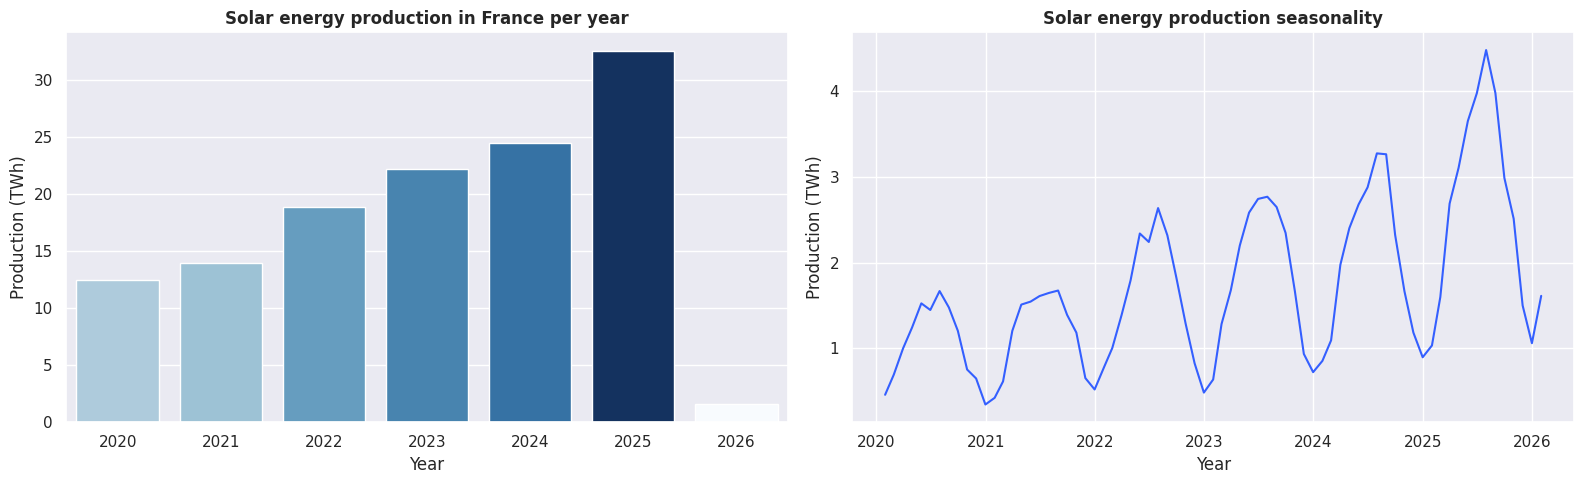

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Energy consumption
yearly_df = (solar_prod_df
             .groupby(solar_prod_df['date'].dt.to_period('Y'))['TWh'] # Using dt.to_period to get clean labels
             .sum()
             .reset_index()
             )

sns.barplot(data=yearly_df,
            x='date', 
            y='TWh',
            hue='TWh',
            palette='Blues', 
            ax=axes[0])

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Production (TWh)")
axes[0].set_title("Solar energy production in France per year", fontweight="bold")
axes[0].legend().remove()


monthly_df = (solar_prod_df
              .groupby(pd.Grouper(key='date', freq='ME'))['TWh']
              .sum()
              .reset_index()
              )

sns.lineplot(data=monthly_df,
            x='date', 
            y='TWh',
            palette='Blues',
            ax=axes[1])

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Production (TWh)")
axes[1].set_title("Solar energy production seasonality", fontweight="bold")


plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; D. Evolution of solar production by months

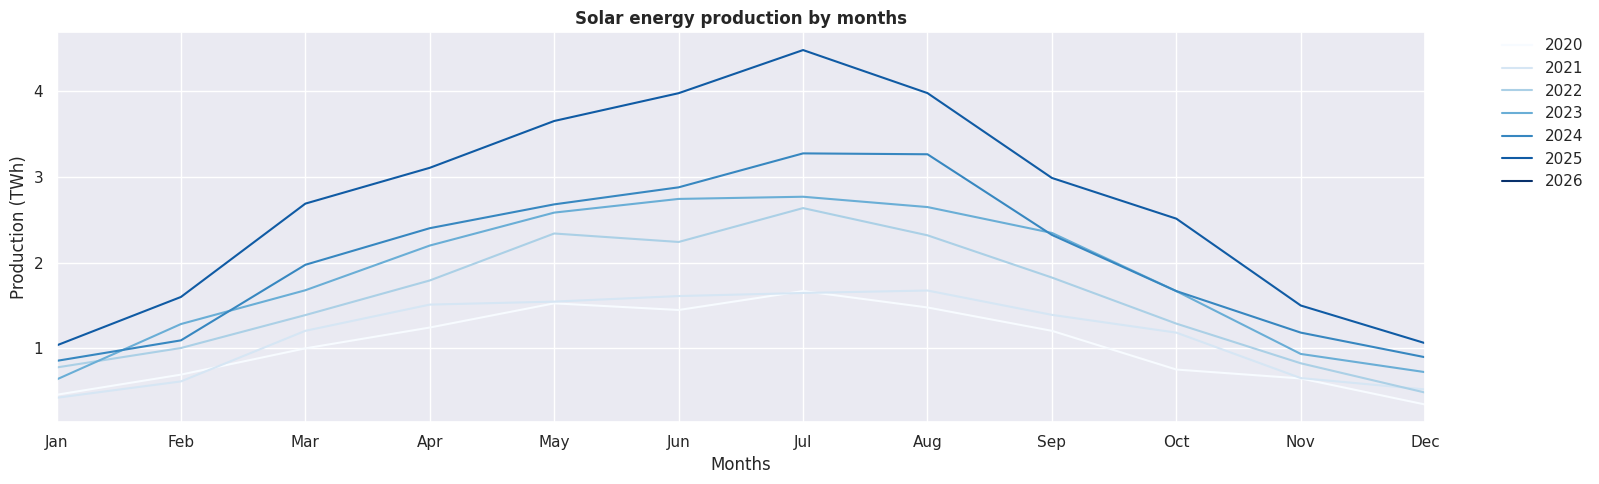

In [63]:
month_year_df = (solar_prod_df
              .groupby([solar_prod_df['date'].dt.to_period('M')])['TWh']
              .sum()
              .reset_index()
              )

month_year_df['date'] = month_year_df['date'].dt.to_timestamp()
month_year_df['year'] = month_year_df['date'].dt.year
month_year_df['month'] = month_year_df['date'].dt.month


fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=month_year_df,
                x='month', 
                y='TWh', 
                hue='year',
                palette='Blues',
                markers=True,
                dashes=False,
                ax=ax
                )

ax.set_xlabel("Months")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by months", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.legend(bbox_to_anchor=(1.12, 1), borderaxespad=0, frameon=False) # Put legend out of the graph

# Show all x labels and customize the labels
ax.set_xticks(range(1, 13)) # Setting up 12 marks
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; E. Solar production and atmospheric radiation relation

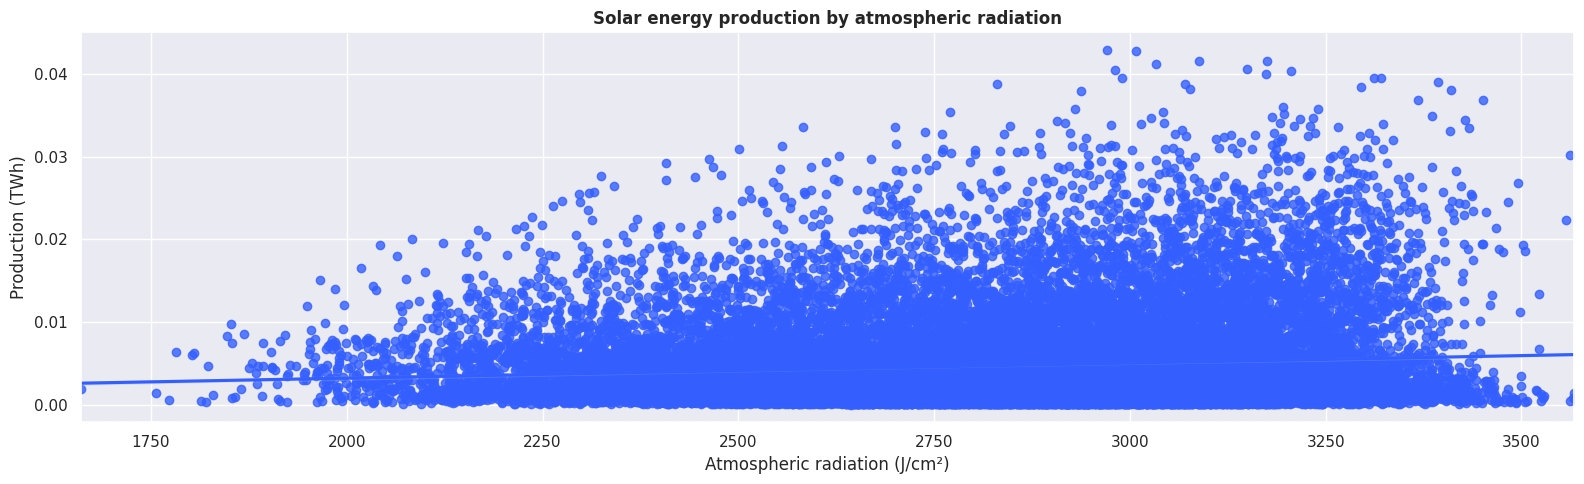

In [64]:
fig, ax = plt.subplots(figsize=(16, 5))

sns.regplot(data=solar_prod_df,
                x='atmospheric_radiation', 
                y='TWh', 
                ax=ax
                )

ax.set_xlabel("Atmospheric radiation (J/cm²)")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by atmospheric radiation", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; F. Correlation between meteorological variables and solar production

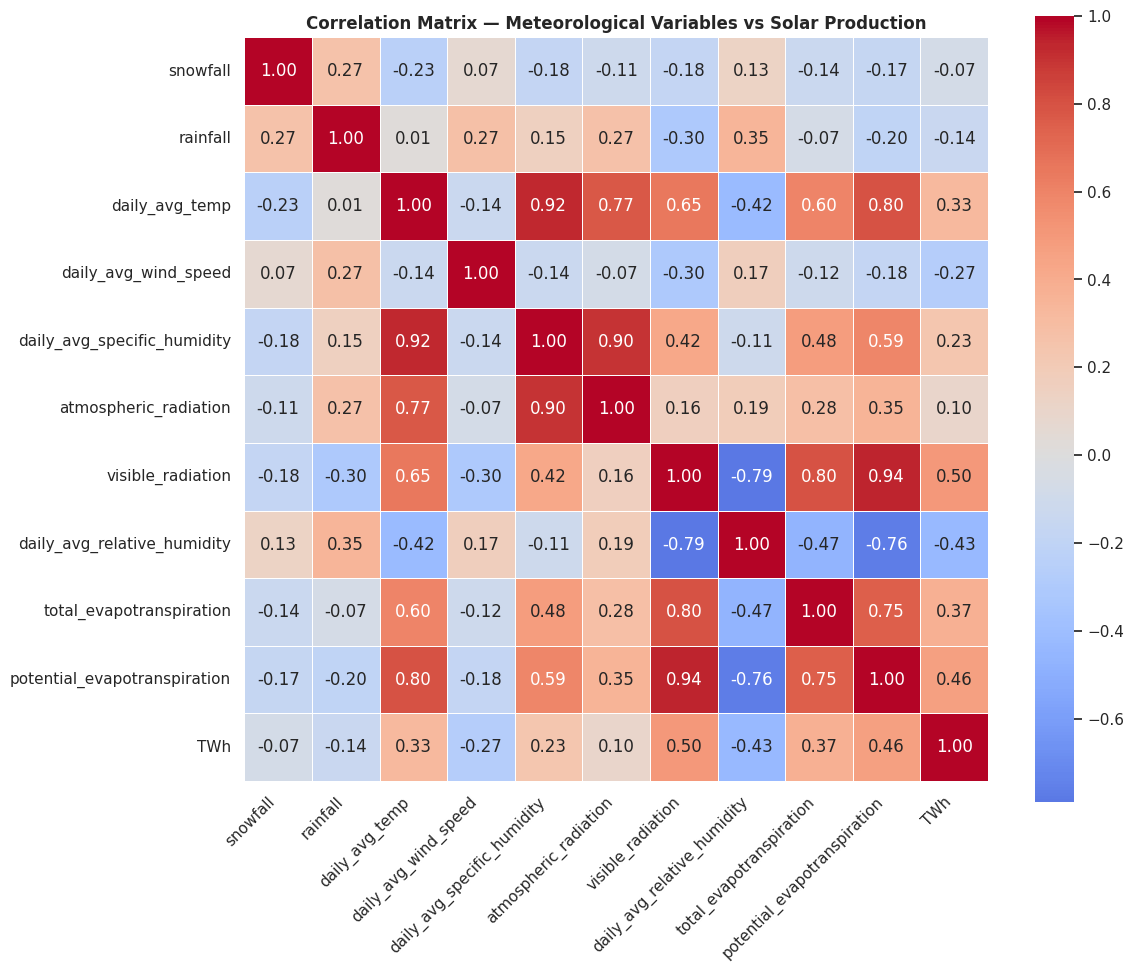

In [65]:
meteo_cols = ['snowfall', 'rainfall', 'daily_avg_temp', 'daily_avg_wind_speed', 
              'daily_avg_specific_humidity', 'atmospheric_radiation', 
              'visible_radiation', 'daily_avg_relative_humidity', 
              'total_evapotranspiration', 'potential_evapotranspiration', 'TWh'
              ]

corr = solar_prod_df[meteo_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5, 
            ax=ax
            )

# Getting nice and clean x-axis, no legend colliding
ax.set_xticklabels(ax.get_xticklabels(),
                    rotation=45,
                    ha='right'
                    )
ax.set_title('Correlation Matrix — Meteorological Variables vs Solar Production', fontweight='bold')
plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; G. Top 4 correlations with TWh

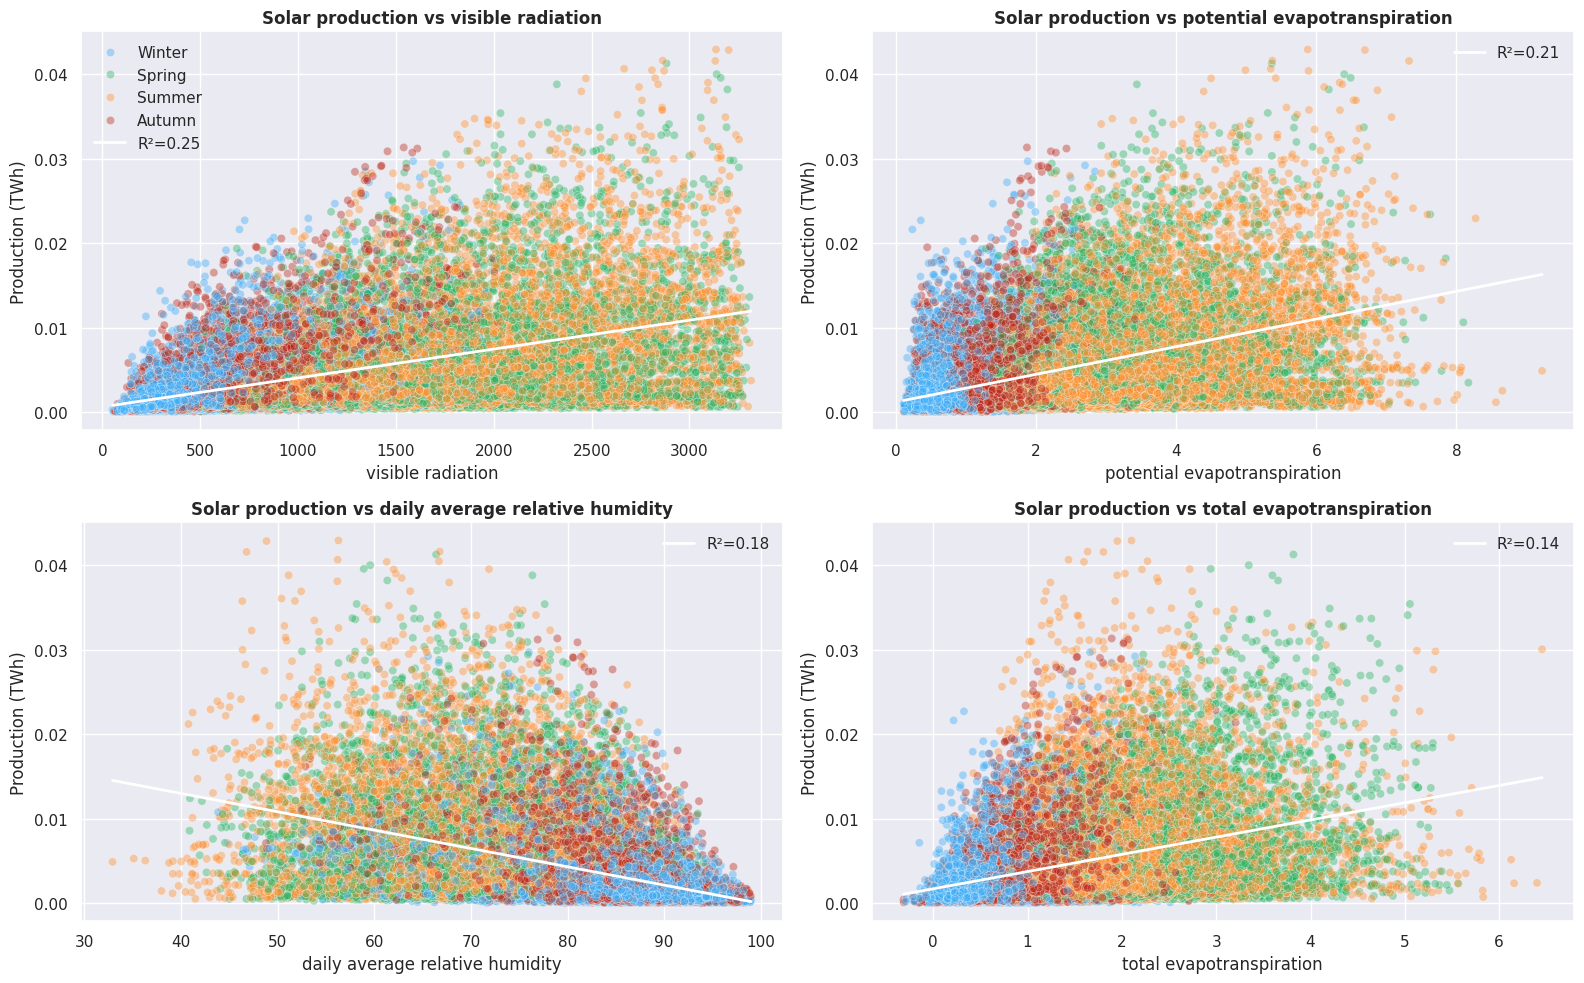

In [66]:
# Function to translate date into season
def get_season(date):
    m = date.month
    d = date.day
    if (m == 12 and d >= 21) or m in [1, 2] or (m == 3 and d < 20):
        return 'Winter'

    elif (m == 3 and d >= 20) or m in [4, 5] or (m == 6 and d < 21):
        return 'Spring'

    elif (m == 6 and d >= 21) or m in [7, 8] or (m == 9 and d < 23):
        return 'Summer'

    else:
        return 'Autumn'

season_palette = {
    'Winter': "#3CACF7",
    'Spring': "#25B360",
    'Summer': "#FF8F2D",
    'Autumn': "#BB2515",
}    

solar_prod_season_df = solar_prod_df.copy()
corr = solar_prod_season_df[meteo_cols].corr()
solar_prod_season_df['Season'] = solar_prod_season_df['date'].apply(get_season)
# Keep the top 4 correlated variables with TWh
top_corr = corr['TWh'].drop('TWh').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()


for i, col in enumerate(top_corr):
    sns.scatterplot(
        data=solar_prod_season_df,
        x=col,
        y='TWh',
        hue='Season',
        hue_order=['Winter', 'Spring', 'Summer', 'Autumn'],
        palette=season_palette,
        alpha=0.4,
        ax=axes[i],
        legend=(i == 0)
    )
    x_clean = solar_prod_season_df[[col, 'TWh']].dropna()
    slope, intercept, r, *_ = stats.linregress(x_clean[col], x_clean['TWh'])
    x_range = np.linspace(x_clean[col].min(), x_clean[col].max(), 100)
    axes[i].plot(x_range, slope * x_range + intercept, color='white', linewidth=2, label=f'R²={r**2:.2f}')
    axes[i].legend(frameon=False)
    axes[i].set_title(f'Solar production vs {col.replace("_", " ").replace("avg", "average")}', fontweight='bold')
    axes[i].set_xlabel(f'{col.replace("_", " ").replace("avg", "average")}')
    axes[i].set_ylabel('Production (TWh)')

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; H. Solar production distribution

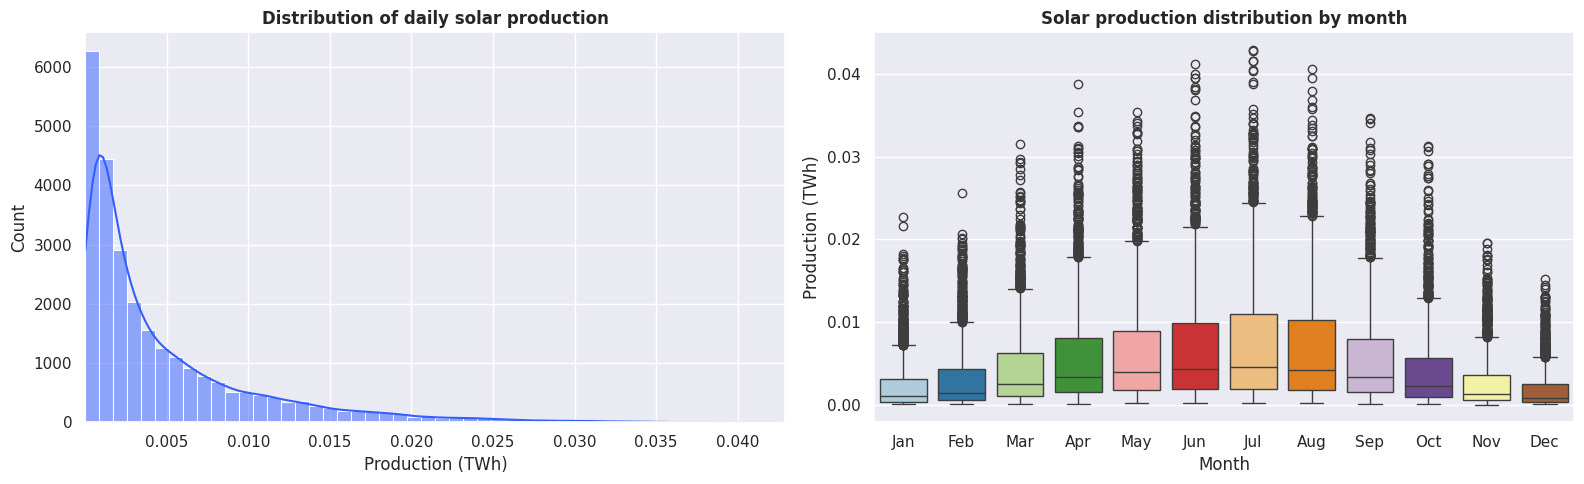

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(data=solar_prod_df, 
             x='TWh', 
             bins=50, 
             kde=True, 
             ax=axes[0], 
             color=palette[0]
             )

axes[0].set_title('Distribution of daily solar production', fontweight='bold')
axes[0].set_xlabel('Production (TWh)')
axes[0].margins(x=0) # To start the graph at the Y axis and leave no space

# Boxplot per month
sns.boxplot(data=solar_prod_df, 
            x=solar_prod_df['date'].dt.month, # Extract month for visualisation
            y='TWh', 
            palette='Paired', 
            ax=axes[1]
            )

axes[1].set_title('Solar production distribution by month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Production (TWh)')
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

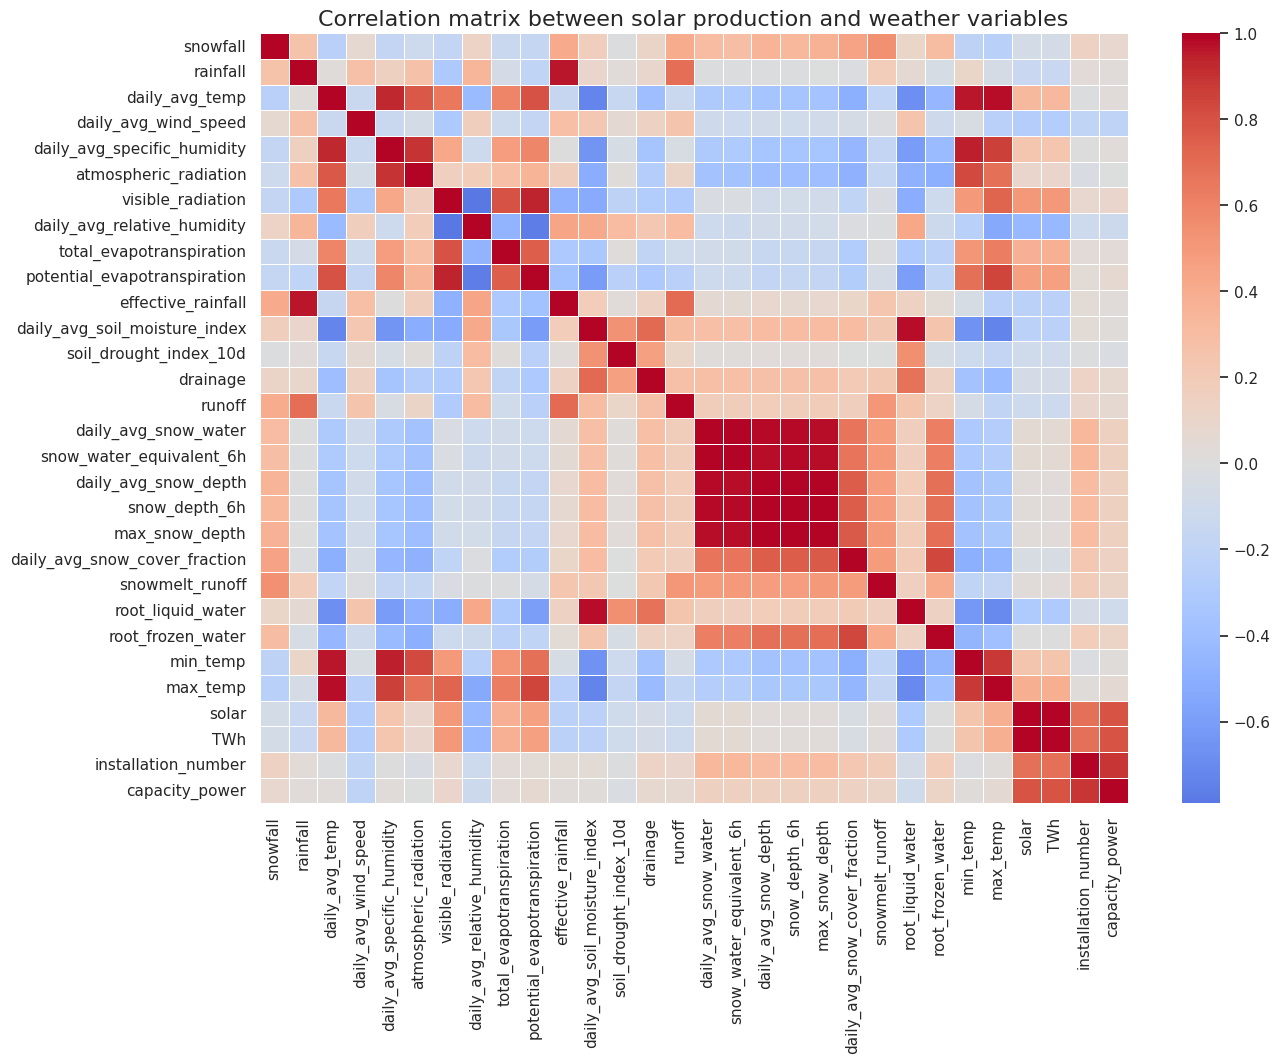

In [68]:
# Choose your final dataset here
# Replace final_df with your actual merged dataframe name if different
df = solar_prod_df.copy()

numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5,
)

plt.title("Correlation matrix between solar production and weather variables", fontsize=16)
plt.show()

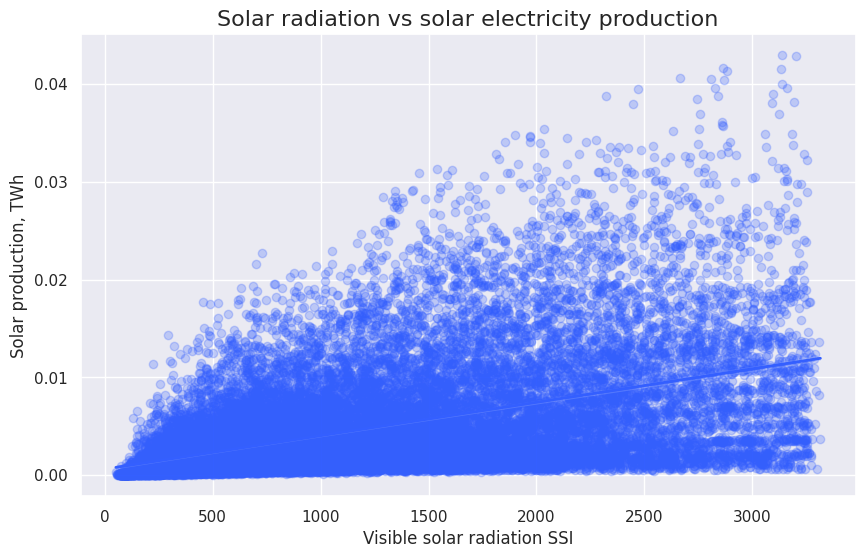

In [69]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="visible_radiation",
    y="TWh",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Solar radiation vs solar electricity production", fontsize=16)
plt.xlabel("Visible solar radiation SSI")
plt.ylabel("Solar production, TWh")
plt.show()

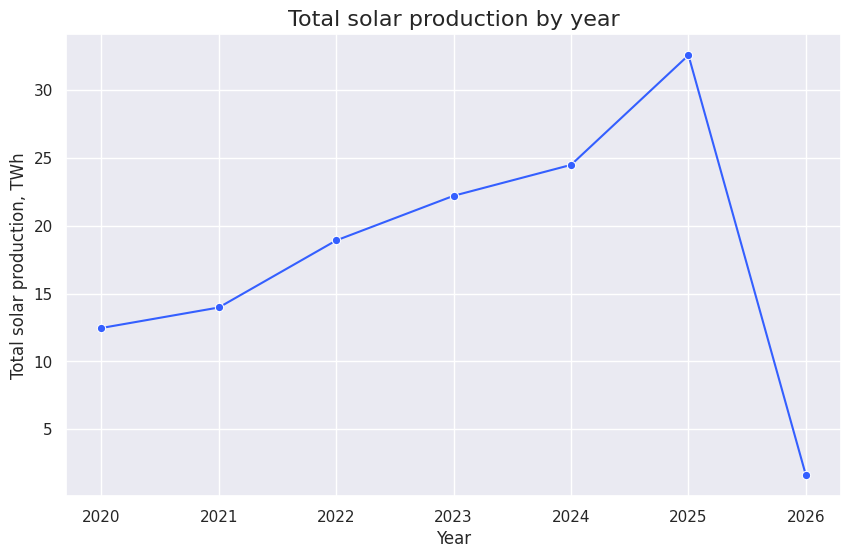

In [70]:
df["year"] = df["date"].dt.year

yearly = (
    df.groupby("year")["TWh"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly,
    x="year",
    y="TWh",
    marker="o"
)

plt.title("Total solar production by year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total solar production, TWh")
plt.show()

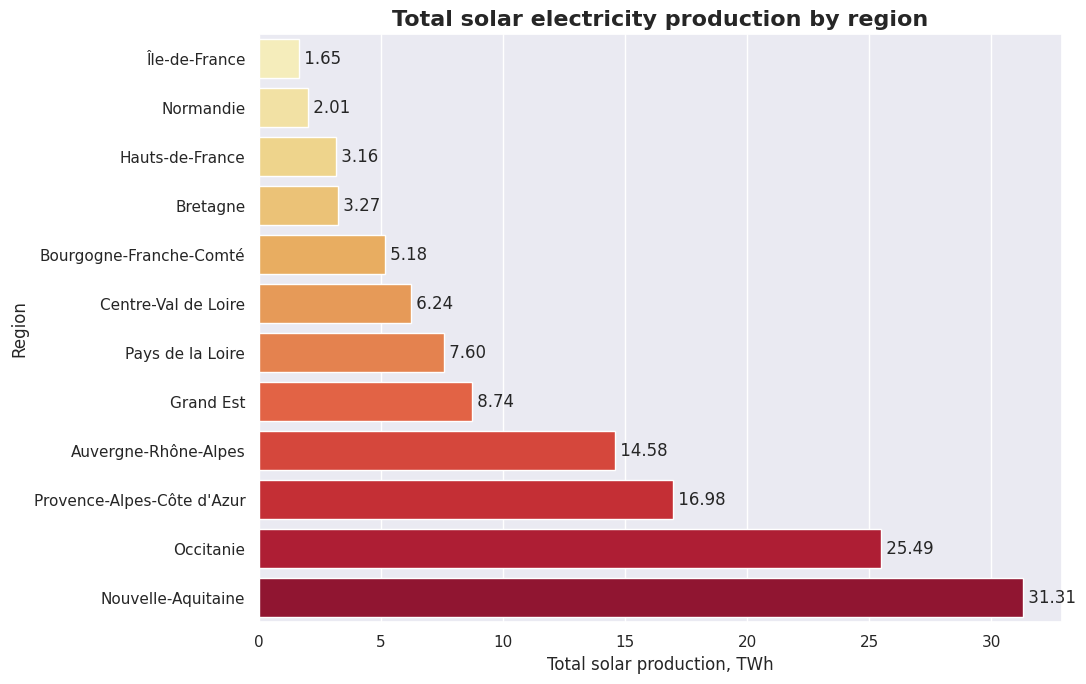

In [71]:
region_prod = (
    df.groupby("region", as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
    .sort_values("total_solar_TWh", ascending=True)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=region_prod,
    x="total_solar_TWh",
    y="region",
    palette="YlOrRd"
)

plt.title("Total solar electricity production by region", fontsize=16, weight="bold")
plt.xlabel("Total solar production, TWh")
plt.ylabel("Region")

for index, value in enumerate(region_prod["total_solar_TWh"]):
    plt.text(value, index, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

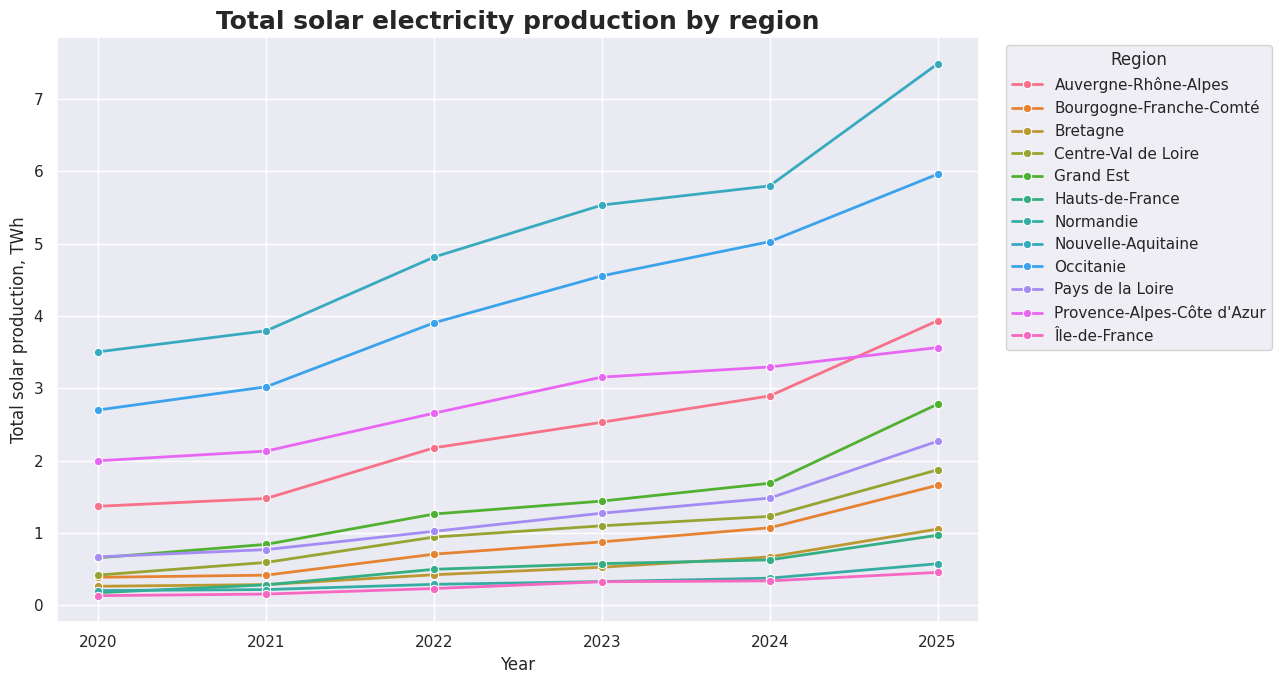

In [72]:
plot_df = df.copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year

# Remove incomplete year
plot_df = plot_df[plot_df["year"] < 2026]

year_region = (
    plot_df
    .groupby(["year", "region"], as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=year_region,
    x="year",
    y="total_solar_TWh",
    hue="region",
    marker="o",
    linewidth=2
)

plt.title(
    "Total solar electricity production by region",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total solar production, TWh", fontsize=12)

plt.xticks(sorted(year_region["year"].unique()))

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 💹 3. Machine Learning

### &nbsp;&nbsp;&nbsp; A. Linear Regression Model

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 1: Only dataset data

In [73]:
ml_df = solar_prod_df.copy() 

# =========================
# 1. Préparation des données
# =========================

# Conversion de la date
ml_df["date"] = pd.to_datetime(ml_df["date"])

# Tri chronologique
ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé


# =========================
# 2. Création de la cible J+1
# =========================

ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y
X = ml_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = ml_df["target"]

# =========================
# 4. Découpage train / test
# =========================

train = ml_df[ml_df["date"] < "2024-01-01"]
test = ml_df[ml_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]


# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocessings on train set
X_train = preprocessor.fit_transform(X_train)


# Preprocessings on test set
X_test = preprocessor.transform(X_test) # Don't fit again !!

# =========================
# 5. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions train / test
# =========================

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# =========================
# 7. Evaluation train / test
# =========================

print("===== Scores Train =====")
print("Train R² :", round(r2_score(y_train, y_pred_train), 3))
print("Train MAE :", round(mean_absolute_error(y_train, y_pred_train), 3))
print("Train RMSE :", round(mean_squared_error(y_train, y_pred_train)**0.5, 3))

print()

print("===== Scores Test =====")
print("Test R² :", round(r2_score(y_test, y_pred_test), 3))
print("Test MAE :", round(mean_absolute_error(y_test, y_pred_test), 3))
print("Test RMSE :", round(mean_squared_error(y_test, y_pred_test)**0.5, 3))

# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

===== Scores Train =====
Train R² : 0.765
Train MAE : 302.847
Train RMSE : 399.195

===== Scores Test =====
Test R² : 0.761
Test MAE : 300.849
Test RMSE : 395.234
count    26676.000000
mean      1198.918363
std        819.419783
min         52.254064
25%        489.082210
50%       1036.947391
75%       1772.010875
max       3314.624151
Name: visible_radiation, dtype: float64
                                  Variable   Coefficient
10                 num__effective_rainfall  22699.824033
1                            num__rainfall -20709.837653
8            num__total_evapotranspiration   5419.043840
0                            num__snowfall  -3196.234323
15               num__daily_avg_snow_water   2762.003250
16           num__snow_water_equivalent_6h  -2503.073004
17               num__daily_avg_snow_depth  -1691.019018
19                     num__max_snow_depth   1038.246719
22                  num__root_liquid_water   -928.214669
11      num__daily_avg_soil_moisture_index    893.3

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 2: Adding previous days' radiation to explanatory variables 

In [74]:
ml_df = ml_df.sort_values(
    ["region", "date"]
)

corrs = []

for lag in range(1,31):

    corr = (
        ml_df["visible_radiation"]
        .corr(
            ml_df.groupby("region")
                 ["visible_radiation"]
                 .shift(lag)
        )
    )

    corrs.append(corr)

    print(
        f"Lag {lag}: {corr:.3f}"
    )

Lag 1: 0.856
Lag 2: 0.779
Lag 3: 0.743
Lag 4: 0.721
Lag 5: 0.702
Lag 6: 0.691
Lag 7: 0.683
Lag 8: 0.684
Lag 9: 0.679
Lag 10: 0.678
Lag 11: 0.679
Lag 12: 0.674
Lag 13: 0.673
Lag 14: 0.665
Lag 15: 0.655
Lag 16: 0.651
Lag 17: 0.646
Lag 18: 0.644
Lag 19: 0.641
Lag 20: 0.636
Lag 21: 0.637
Lag 22: 0.641
Lag 23: 0.640
Lag 24: 0.636
Lag 25: 0.629
Lag 26: 0.616
Lag 27: 0.611
Lag 28: 0.601
Lag 29: 0.591
Lag 30: 0.584


In [75]:
pacf_values, confint = pacf(
    ml_df["visible_radiation"],
    nlags=30,
    alpha=0.05
)

pacf_df = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "PACF": pacf_values,
    "IC_inf": confint[:,0],
    "IC_sup": confint[:,1]
})

display(pacf_df.round(3))

,Lag,PACF,IC_inf,IC_sup
0,0,1.000,1.000,1.000
1,1,0.856,0.844,0.868
2,2,0.174,0.162,0.186
3,3,0.167,0.155,0.179
4,4,0.126,0.114,0.138
5,5,0.085,0.073,0.097
6,6,0.092,0.080,0.104
7,7,0.076,0.064,0.088
8,8,0.099,0.087,0.111
9,9,0.057,0.045,0.069


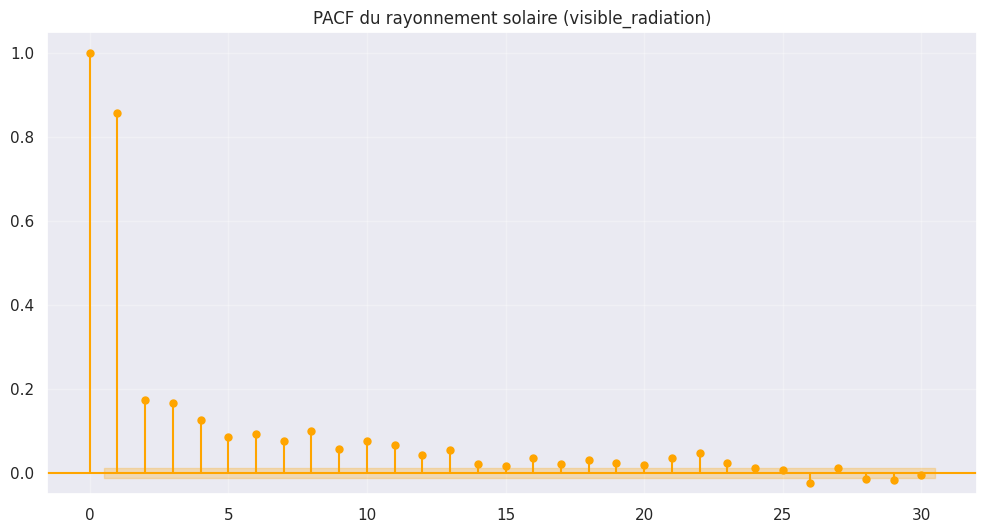

In [76]:
fig, ax = plt.subplots(figsize=(12,6))

plot_pacf(
    ml_df["visible_radiation"],
    lags=30,
    ax=ax
)

# Couleur orange
for line in ax.lines:
    line.set_color("orange")

for collection in ax.collections:
    collection.set_color("orange")

# Zoom vertical
ax.set_ylim(-0.05, 1.05)

# Grille
ax.grid(True, alpha=0.3)

# Titre plus explicite
ax.set_title(
    "PACF du rayonnement solaire (visible_radiation)"
)

plt.show()

In [77]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 2. Création de la cible J+1
# =========================

ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y
X = ml_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = ml_df["target"]



# =========================
# 4. Découpage train / test
# =========================

train = ml_df[ml_df["date"] < "2024-01-01"]
test = ml_df[ml_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Preprocessings on train set
X_train = preprocessor.fit_transform(X_train)


# Preprocessings on test set
X_test = preprocessor.transform(X_test) # Don't fit again !!

# =========================
# 5. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions train / test
# =========================

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# =========================
# 7. Evaluation train / test
# =========================

print("===== Scores Train =====")
print("Train R² :", round(r2_score(y_train, y_pred_train), 3))
print("Train MAE :", round(mean_absolute_error(y_train, y_pred_train), 3))
print("Train RMSE :", round(mean_squared_error(y_train, y_pred_train)**0.5, 3))

print()

print("===== Scores Test =====")
print("Test R² :", round(r2_score(y_test, y_pred_test), 3))
print("Test MAE :", round(mean_absolute_error(y_test, y_pred_test), 3))
print("Test RMSE :", round(mean_squared_error(y_test, y_pred_test)**0.5, 3))
# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

===== Scores Train =====
Train R² : 0.777
Train MAE : 294.445
Train RMSE : 388.945

===== Scores Test =====
Test R² : 0.778
Test MAE : 287.542
Test RMSE : 380.512
count    26676.000000
mean      1198.918363
std        819.419783
min         52.254064
25%        489.082210
50%       1036.947391
75%       1772.010875
max       3314.624151
Name: visible_radiation, dtype: float64
                                  Variable   Coefficient
10                 num__effective_rainfall  16058.207484
1                            num__rainfall -14695.230010
8            num__total_evapotranspiration   3848.762450
15               num__daily_avg_snow_water   2879.804635
16           num__snow_water_equivalent_6h  -2721.464310
0                            num__snowfall  -2270.815464
17               num__daily_avg_snow_depth  -1731.205275
19                     num__max_snow_depth   1016.285002
11      num__daily_avg_soil_moisture_index    854.120929
22                  num__root_liquid_water   -844.8

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 3: Adding day of year data

In [78]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# Ajout des données sur le jour de l'année - Modèle 3

ml_df["day_sin"] = np.sin(
    2*np.pi*ml_df["date"].dt.dayofyear/365
)

ml_df["day_cos"] = np.cos(
    2*np.pi*ml_df["date"].dt.dayofyear/365
)

# =========================
# 2. Création de la cible J+1
# =========================


ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y

X = ml_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = ml_df["target"]


# =========================
# 4. Découpage train / test
# =========================

train = ml_df[ml_df["date"] < "2024-01-01"]
test = ml_df[ml_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]


# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Preprocessings on train set

X_train = preprocessor.fit_transform(X_train)


# Preprocessings on test set
X_test = preprocessor.transform(X_test) # Don't fit again !!

# =========================
# 5. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions train / test
# =========================

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# =========================
# 7. Evaluation train / test
# =========================

print("===== Scores Train =====")
print("Train R² :", round(r2_score(y_train, y_pred_train), 3))
print("Train MAE :", round(mean_absolute_error(y_train, y_pred_train), 3))
print("Train RMSE :", round(mean_squared_error(y_train, y_pred_train)**0.5, 3))

print()

print("===== Scores Test =====")
print("Test R² :", round(r2_score(y_test, y_pred_test), 3))
print("Test MAE :", round(mean_absolute_error(y_test, y_pred_test), 3))
print("Test RMSE :", round(mean_squared_error(y_test, y_pred_test)**0.5, 3))

# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

===== Scores Train =====
Train R² : 0.791
Train MAE : 287.726
Train RMSE : 376.812

===== Scores Test =====
Test R² : 0.792
Test MAE : 279.413
Test RMSE : 368.461
count    26676.000000
mean      1198.918363
std        819.419783
min         52.254064
25%        489.082210
50%       1036.947391
75%       1772.010875
max       3314.624151
Name: visible_radiation, dtype: float64
                                  Variable   Coefficient
10                 num__effective_rainfall  18582.665398
1                            num__rainfall -16991.220426
8            num__total_evapotranspiration   4372.702933
0                            num__snowfall  -2631.545434
15               num__daily_avg_snow_water   1091.950558
16           num__snow_water_equivalent_6h  -1066.383862
19                     num__max_snow_depth    803.664904
2                      num__daily_avg_temp   -719.233788
11      num__daily_avg_soil_moisture_index    643.172458
22                  num__root_liquid_water   -639.6

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 4 - Using TimeSeriesSplit

In [79]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# Ajout des données sur le jour de l'année - Modèle 3

ml_df["day_sin"] = np.sin(
    2*np.pi*ml_df["date"].dt.dayofyear/365
)

ml_df["day_cos"] = np.cos(
    2*np.pi*ml_df["date"].dt.dayofyear/365
)

# =========================
# 2. Création de la cible J+1
# =========================


ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Tri par date
# =========================

ml_df = ml_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = ml_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y = ml_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    # Prédictions sur le train
    
    y_pred_train = model.predict(X_train_scaled)
    
    # # Prédictions sur le test
    y_pred_test = model.predict(X_test_scaled)
    
    # Scores train
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Scores test
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(results)


# =========================
# 6. Coefficients du dernier modèle
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)


print("===== Coefficients du dernier fold =====")
display(coefficients)

# =========================
# 7. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-01,2021-01-04,2021-01-04,2022-01-08,0.660949,320.313786,442.198732,0.801216,289.131700,380.489335,0.740771,295.216717,386.657675
1,2,2020-01-01,2022-01-08,2022-01-08,2023-01-12,0.739633,323.713362,449.688645,0.778618,289.952191,380.191801,0.806077,298.028958,388.090528
2,3,2020-01-01,2023-01-12,2023-01-12,2024-01-16,0.718892,308.689236,420.317557,0.792223,290.381372,380.458211,0.795321,273.596399,358.655310
3,4,2020-01-01,2024-01-16,2024-01-16,2025-01-19,0.650399,321.469980,438.769203,0.793481,285.744399,374.677885,0.755222,278.620981,367.143233
4,5,2020-01-01,2025-01-19,2025-01-19,2026-01-23,0.735084,319.966030,443.963489,0.788272,284.023132,372.748568,0.808209,287.292775,377.752784


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.790762,287.846559,377.713160
2,Test,0.781120,286.551166,375.659906


===== Coefficients du dernier fold =====


,Variable,Coefficient
10,num__effective_rainfall,5485.487558
1,num__rainfall,-5111.895850
8,num__total_evapotranspiration,1288.447824
16,num__snow_water_equivalent_6h,-1047.168670
15,num__daily_avg_snow_water,1045.931309
0,num__snowfall,-806.810039
2,num__daily_avg_temp,-706.606083
19,num__max_snow_depth,670.815070
22,num__root_liquid_water,-637.651624
11,num__daily_avg_soil_moisture_index,628.540220



===== Statistiques visible_radiation =====
count    26676.000000
mean      1198.918363
std        819.419783
min         52.254064
25%        489.082210
50%       1036.947391
75%       1772.010875
max       3314.624151
Name: visible_radiation, dtype: float64


### &nbsp;&nbsp;&nbsp; B. Random Forest Model

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 1: Basic Random Forest

In [80]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)


# Lags J-1, J-2, J-3


ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)


# Variables saisonnières


ml_df["day_sin"] = np.sin(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

ml_df["day_cos"] = np.cos(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Création de la cible J+1
# =========================


ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Tri par date
# =========================

ml_df = ml_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = ml_df.drop(columns=["date", "solar", "target", "installation_number", "capacity_power"])
y = ml_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        random_state=42,
        n_jobs=-1
        )

    model.fit(X_train_scaled, y_train)

    # Prédictions sur le train
    
    y_pred_train = model.predict(X_train_scaled)
    
    # # Prédictions sur le test
    y_pred_test = model.predict(X_test_scaled)
    
    # Scores train
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Scores test
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(results)

# =========================
# 6. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

print()
print("===== Importance des variables Random Forest =====")
print(importances)

# =========================
# 7. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-01,2021-01-04,2021-01-04,2022-01-08,0.660949,320.313786,442.198732,0.974469,103.203594,136.358732,0.743535,294.973131,384.590499
1,2,2020-01-01,2022-01-08,2022-01-08,2023-01-12,0.739633,323.713362,449.688645,0.966492,113.151939,147.911873,0.792952,307.124045,401.009352
2,3,2020-01-01,2023-01-12,2023-01-12,2024-01-16,0.718892,308.689236,420.317557,0.965175,119.087859,155.758286,0.782462,281.081634,369.750231
3,4,2020-01-01,2024-01-16,2024-01-16,2025-01-19,0.650399,321.469980,438.769203,0.960066,126.132417,164.758064,0.764653,274.809420,360.001179
4,5,2020-01-01,2025-01-19,2025-01-19,2026-01-23,0.735084,319.966030,443.963489,0.955461,131.525449,170.960475,0.816465,281.152684,369.531956


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.964333,118.620252,155.149486
2,Test,0.780014,287.828183,376.976643



===== Importance des variables Random Forest =====
                                  Variable  Importance
9        num__potential_evapotranspiration    0.555687
6                   num__visible_radiation    0.149709
30                  num__radiation_7d_mean    0.085797
35                            num__day_cos    0.024146
1                            num__rainfall    0.020182
10                 num__effective_rainfall    0.012694
34                            num__day_sin    0.012514
26                                num__TWh    0.009096
28                       num__radiation_J2    0.008476
29                       num__radiation_J3    0.007920
3                num__daily_avg_wind_speed    0.007837
27                       num__radiation_J1    0.007756
33                    num__rainfall_7d_sum    0.007656
8            num__total_evapotranspiration    0.007427
12             num__soil_drought_index_10d    0.007420
14                             num__runoff    0.006838
32           

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 2: increase parameters

In [81]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)


#  Lags J-1, J-2, J-3


ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)


# Variables saisonnières


ml_df["day_sin"] = np.sin(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

ml_df["day_cos"] = np.cos(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Création de la cible J+1
# =========================


ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Tri par date
# =========================

ml_df = ml_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = ml_df.drop(columns=["date", "solar", "target", "installation_number", "capacity_power"])
y = ml_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=20,
        random_state=42,
        n_jobs=-1
        )

    model.fit(X_train_scaled, y_train)

    # Prédictions sur le train
    
    y_pred_train = model.predict(X_train_scaled)
    
    # # Prédictions sur le test
    y_pred_test = model.predict(X_test_scaled)
    
    # Scores train
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Scores test
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(results)

# =========================
# 6. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

print()
print("===== Importance des variables Random Forest =====")
print(importances)

# =========================
# 7. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-01,2021-01-04,2021-01-04,2022-01-08,0.660949,320.313786,442.198732,0.978363,93.358540,125.530608,0.743513,295.282994,384.607047
1,2,2020-01-01,2022-01-08,2022-01-08,2023-01-12,0.739633,323.713362,449.688645,0.975533,94.861322,126.393590,0.793152,307.344058,400.815566
2,3,2020-01-01,2023-01-12,2023-01-12,2024-01-16,0.718892,308.689236,420.317557,0.976677,95.919550,127.469022,0.782162,281.654579,370.004835
3,4,2020-01-01,2024-01-16,2024-01-16,2025-01-19,0.650399,321.469980,438.769203,0.975279,97.974574,129.631765,0.764640,274.943118,360.010903
4,5,2020-01-01,2025-01-19,2025-01-19,2026-01-23,0.735084,319.966030,443.963489,0.973960,99.212722,130.721512,0.816251,281.592501,369.747515


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.975962,96.265342,127.949300
2,Test,0.779944,288.163450,377.037173



===== Importance des variables Random Forest =====
                                  Variable  Importance
9        num__potential_evapotranspiration    0.540454
6                   num__visible_radiation    0.146848
30                  num__radiation_7d_mean    0.084864
35                            num__day_cos    0.024261
1                            num__rainfall    0.020807
10                 num__effective_rainfall    0.013150
34                            num__day_sin    0.013015
26                                num__TWh    0.010050
28                       num__radiation_J2    0.009556
27                       num__radiation_J1    0.008914
29                       num__radiation_J3    0.008905
3                num__daily_avg_wind_speed    0.008857
33                    num__rainfall_7d_sum    0.008572
12             num__soil_drought_index_10d    0.008322
8            num__total_evapotranspiration    0.008183
14                             num__runoff    0.007444
32           

### &nbsp;&nbsp;&nbsp; C. Boosting model

In [82]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)


# Lags J-1, J-2, J-3


ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)


# Variables saisonnières


ml_df["day_sin"] = np.sin(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

ml_df["day_cos"] = np.cos(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Création de la cible J+1
# =========================


ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
ml_df = ml_df.dropna()

# =========================
# 3. Tri par date
# =========================

ml_df = ml_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = ml_df.drop(columns=["date", "solar", "target", "installation_number", "capacity_power"])
y = ml_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
        )

    model.fit(X_train_scaled, y_train)

    # Prédictions sur le train
    
    y_pred_train = model.predict(X_train_scaled)
    
    # # Prédictions sur le test
    y_pred_test = model.predict(X_test_scaled)
    
    # Scores train
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Scores test
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(results)

# =========================
# 6. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

print()
print("===== Importance des variables Random Forest =====")
print(importances)

# =========================
# 7. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-01,2021-01-04,2021-01-04,2022-01-08,0.660949,320.313786,442.198732,0.927162,178.816518,230.319461,0.739763,293.558779,387.408583
1,2,2020-01-01,2022-01-08,2022-01-08,2023-01-12,0.739633,323.713362,449.688645,0.883165,212.863128,276.195754,0.798944,299.828392,395.164167
2,3,2020-01-01,2023-01-12,2023-01-12,2024-01-16,0.718892,308.689236,420.317557,0.873789,227.641151,296.521918,0.796354,268.473702,357.749216
3,4,2020-01-01,2024-01-16,2024-01-16,2025-01-19,0.650399,321.469980,438.769203,0.861395,234.118157,306.949829,0.783559,263.354002,345.238438
4,5,2020-01-01,2025-01-19,2025-01-19,2026-01-23,0.735084,319.966030,443.963489,0.850300,239.210284,313.427869,0.819855,278.264744,366.103449


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.879162,218.529848,284.682966
2,Test,0.787695,280.695924,370.332771



===== Importance des variables Random Forest =====
                                  Variable  Importance
9        num__potential_evapotranspiration    0.456050
6                   num__visible_radiation    0.229574
30                  num__radiation_7d_mean    0.108949
35                            num__day_cos    0.032238
10                 num__effective_rainfall    0.013116
1                            num__rainfall    0.010528
23                  num__root_frozen_water    0.010221
46  cat__region_Provence-Alpes-Côte d'Azur    0.008008
34                            num__day_sin    0.007718
28                       num__radiation_J2    0.005948
26                                num__TWh    0.005326
14                             num__runoff    0.005252
29                       num__radiation_J3    0.005011
19                     num__max_snow_depth    0.004847
20      num__daily_avg_snow_cover_fraction    0.004601
8            num__total_evapotranspiration    0.004498
38           

### &nbsp;&nbsp;&nbsp; D. Finale Model

In [83]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)


# Lags J-1, J-2, J-3


ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


#  Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)


#  Variables saisonnières


ml_df["day_sin"] = np.sin(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

ml_df["day_cos"] = np.cos(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Cible J+1 par région
# =========================

ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 3. Tri par date
# =========================

ml_df = ml_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

ml_df = ml_df.sort_values(["date", "region"]).reset_index(drop=True)


# =========================
# 4. Séparation X / y
# =========================

features = [
    "radiation_7d_mean",
    "visible_radiation",
    "radiation_J1",
    "radiation_J2",
    "radiation_J3",
    "potential_evapotranspiration",
    "day_cos"
]

X = ml_df[features]
y = ml_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

train_r2_scores = []
train_mae_scores = []
train_rmse_scores = []

test_r2_scores = []
test_mae_scores = []
test_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    # Prédictions sur le train
    
    y_pred_train = model.predict(X_train_scaled)
    
    # # Prédictions sur le test
    y_pred_test = model.predict(X_test_scaled)
    
    # Scores train
    train_r2 = r2_score(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Scores test
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    train_r2_scores.append(train_r2)
    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    test_r2_scores.append(test_r2)
    test_mae_scores.append(test_mae)
    test_rmse_scores.append(test_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Train R²": train_r2,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Test R²": test_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Train", "Test"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores)
    ]
})

display(results)


,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
0,1,2020-01-01,2021-01-04,2021-01-04,2022-01-08,0.660949,320.313786,442.198732,0.772290,307.748439,407.232801,0.722716,302.037861,399.896269
1,2,2020-01-01,2022-01-08,2022-01-08,2023-01-12,0.739633,323.713362,449.688645,0.751224,305.973904,403.028241,0.789737,309.669589,404.110613
2,3,2020-01-01,2023-01-12,2023-01-12,2024-01-16,0.718892,308.689236,420.317557,0.767253,306.349267,402.670790,0.774881,287.180451,376.137305
3,4,2020-01-01,2024-01-16,2024-01-16,2025-01-19,0.650399,321.469980,438.769203,0.769131,301.611601,396.150430,0.728471,291.162674,386.685564
4,5,2020-01-01,2025-01-19,2025-01-19,2026-01-23,0.735084,319.966030,443.963489,0.763306,299.925667,394.112915,0.784316,305.050672,400.591585


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700991,318.830479,438.987525
1,Train,0.764641,304.321776,400.639035
2,Test,0.760024,299.020249,393.484267


### &nbsp;&nbsp;&nbsp; E. Final Dataframe

In [84]:
ml_df = solar_prod_df.copy()

# =========================
# 1. Préparation des données
# =========================

ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df = ml_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)


# Lags J-1, J-2, J-3


ml_df["radiation_J1"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

ml_df["radiation_J2"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

ml_df["radiation_J3"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)


# Moyennes glissantes par région


ml_df["radiation_7d_mean"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)


ml_df["temp_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["humidity_7d_mean"] = (
    ml_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

ml_df["rainfall_7d_sum"] = (
    ml_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)


# Variables saisonnières


ml_df["day_sin"] = np.sin(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

ml_df["day_cos"] = np.cos(
    2 * np.pi * ml_df["date"].dt.dayofyear / 365
)

# =========================
# Création de la cible J+1
# =========================

ml_df["target"] = (
    ml_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# Tri final
# =========================

ml_df = ml_df.sort_values(
    ["date", "region"]
).reset_index(drop=True)

# =========================
# Features du modèle final
# =========================

features = [
    "radiation_7d_mean",
    "visible_radiation",
    "radiation_J1",
    "radiation_J2",
    "radiation_J3",
    "potential_evapotranspiration",
    "day_cos"
]

# =========================
# DataFrame d'entraînement
# =========================

train_df = ml_df.dropna(
    subset=[
        "target",
        "radiation_7d_mean",
        "radiation_J1",
        "radiation_J2",
        "radiation_J3",
        "potential_evapotranspiration",
        "day_cos"
    ]
).copy()

X_train = train_df[features]
y_train = train_df["target"]

# =========================
# 5. Preprocessing
# =========================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# =========================
# 6. Entraînement final
# =========================

X_train_preprocessed = preprocessor.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_preprocessed, y_train)

# =========================
# 7. Prédiction sur toutes les lignes
# =========================

prediction_mask = ml_df[features].notna().all(axis=1)

ml_df["visible_radiation J+1 predit"] = np.nan

X_pred = ml_df.loc[prediction_mask, features]

X_pred_preprocessed = preprocessor.transform(X_pred)

ml_df.loc[
    prediction_mask,
    "visible_radiation J+1 predit"
] = model.predict(X_pred_preprocessed)


# =========================
# 8. Écart entre réel et prédit
# =========================

ml_df["radiation_J+1 reel"] = ml_df["target"]

ml_df["ecart prediction"] = (
    ml_df["visible_radiation J+1 predit"]
    - ml_df["radiation_J+1 reel"]
)

# =========================
# 9. Conversion du rayonnement actuel en kWh/m²
# =========================

ml_df["Kwh/m2"] = ml_df["visible_radiation"] / 360

# =========================
# 10. Production solaire actuelle estimée
# Hypothèse : rendement panneau = 20 %
# =========================

ml_df["production_solaire/m2(en Kwh)"] = (
    ml_df["Kwh/m2"] * 0.20
)

# =========================
# 11. Conversion de la prédiction J+1
# =========================

ml_df["Kwh/m2 prédit J+1"] = (
    ml_df["visible_radiation J+1 predit"] / 360
)

ml_df["production_solaire/m2(en Kwh) J+1 predit"] = (
    ml_df["Kwh/m2 prédit J+1"] * 0.20
)

# =========================
# 12. Vérification de la dernière ligne
# =========================

display(ml_df.tail())

,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,...,day_sin,day_cos,target,visible_radiation J+1 predit,radiation_J+1 reel,ecart prediction,Kwh/m2,production_solaire/m2(en Kwh),Kwh/m2 prédit J+1,production_solaire/m2(en Kwh) J+1 predit
26671,2026-01-31,Nouvelle-Aquitaine,0.422359,8.325036,7.590883,3.439146,6.067580,2919.537048,373.240159,91.757236,...,0.508671,0.860961,NaN,393.177186,NaN,NaN,1.036778,0.207356,1.092159,0.218432
26672,2026-01-31,Occitanie,1.933858,6.556291,5.446275,3.971026,5.226326,2792.483361,474.453394,87.745530,...,0.508671,0.860961,NaN,473.667152,NaN,NaN,1.317926,0.263585,1.315742,0.263148
26673,2026-01-31,Pays de la Loire,0.000000,3.065784,7.169376,2.317202,5.951136,2954.876181,426.565974,94.257089,...,0.508671,0.860961,NaN,430.362289,NaN,NaN,1.184905,0.236981,1.195451,0.239090
26674,2026-01-31,Provence-Alpes-Côte d'Azur,0.007636,1.315091,2.483091,1.672727,4.177602,2378.269818,395.816909,80.670364,...,0.508671,0.860961,NaN,453.574518,NaN,NaN,1.099491,0.219898,1.259929,0.251986
26675,2026-01-31,Île-de-France,0.000000,0.259574,6.079787,2.130319,5.604101,2928.961170,207.585638,95.445213,...,0.508671,0.860961,NaN,273.623765,NaN,NaN,0.576627,0.115325,0.760066,0.152013


### &nbsp;&nbsp;&nbsp; G. Data export

In [86]:
ml_df.to_csv(
    r'data/solar_prod_predictions.csv',
    index=False
)